## 📋 Executive Summary

**Задача:** построить модель кредитного скоринга для оценки вероятности дефолта заёмщика на основе датасета Home Credit Default Risk (307,511 клиентов, 122 исходных признака).

**Ключевые находки EDA:**
- Жёсткий дисбаланс классов: 91.9% надёжных клиентов vs 8.1% дефолтников — потребовал балансировки и метрик, устойчивых к дисбалансу
- Обнаружены и обработаны системные аномалии в данных: скрытый пропуск в `DAYS_EMPLOYED` (18% клиентов), экстремальные выбросы в доходах
- **Ловушка корреляции:** стандартная корреляция Пирсона занижала силу связи `EXT_SOURCE` с дефолтом (r ≈ -0.15…-0.18) из-за дисбаланса классов — реальный размер эффекта (Cohen's d = 0.60–0.68) оказался значительно выше
- Образование — сильный предиктор риска: от 1.8% дефолтов у людей с учёной степенью до 10.9% у людей с неполным средним образованием

**Модель:**
- LightGBM с балансировкой классов, честное разбиение train/validation/test
- **ROC-AUC: 0.759** на отложенной тестовой выборке

**Калибровка:**
- Исходные вероятности модели были искажены (Brier Score 0.189) из-за балансировки классов
- После изотонической регрессии Brier Score улучшен до **0.068**

**Бизнес-результат (Profit Curve):**
- Переведена модель в денежный эквивалент: найден оптимальный порог отсечения риска - **18.18%**
- При этом пороге модель максимизирует прибыль на тестовой выборке - **7,183,600,000** тенге

**Интерпретируемость:** через SHAP определены ключевые драйверы риска на уровне отдельных признаков и конкретных заёмщиков.

# 🏦 Exploratory Data Analysis (EDA) для Home Credit Default Risk

**Цель проекта:** Проанализировать данные клиентов банка, выявить ключевые паттерны и признаки, влияющие на вероятность дефолта (невозврата кредита), а также подготовить датасет для дальнейшего построения ML-моделей.

## Шаг 1: Загрузка библиотек и данных
Импортируем необходимые инструменты для работы с таблицами, визуализации и проведения статистических тестов.

In [152]:

import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind
from scipy.stats import stats
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator 
from sklearn.model_selection import StratifiedKFold
df = pd.read_csv('application_train.csv')

#1 step: 
print(df.shape)


(307511, 122)


## Шаг 2: Анализ целевой переменной (TARGET)
Проверим баланс классов в датасете. Это критически важно для понимания того, с какой выборкой мы работаем и какие метрики предсказания будем использовать в будущем.


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
(307511, 122)


<Axes: title={'center': 'Баланс классов (0 - вернули, 1 - дефолт)'}, xlabel='TARGET'>

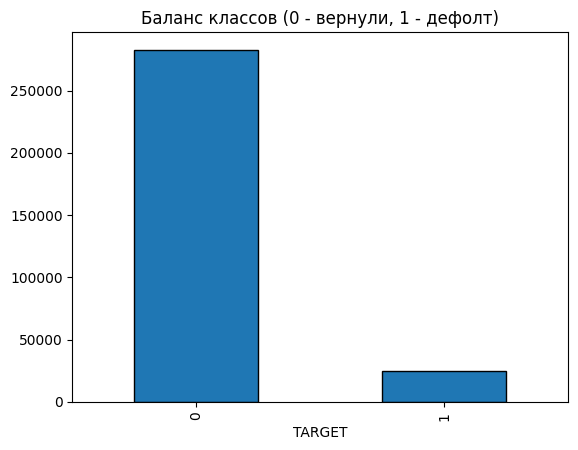

In [153]:
#2 step
print(df['TARGET'].value_counts(normalize=True))
print(df.shape)
df['TARGET'].value_counts().plot(kind='bar', edgecolor = 'black', title='Баланс классов (0 - вернули, 1 - дефолт)')


**💡 Инсайт по целевой переменной:** 
В данных присутствует **жесткий дисбаланс классов** (91.9% надежных против 8.1% дефолтников). Обычная метрика Accuracy здесь будет бесполезна (модель, предсказывающая всем нули, даст 92% точности, но не найдет ни одного должника). Для ML-модели потребуется балансировка (например, SMOTE, веса классов) и оценка через метрику ROC-AUC.

## Шаг 3: Анализ и очистка пропусков (Missing Values)
Многие алгоритмы машинного обучения не умеют работать с пустыми значениями (`NaN`). Посмотрим, какие колонки содержат больше всего "дыр". Признаки, в которых отсутствует более 60% информации, не несут пользы и только зашумляют данные — их мы удалим.

In [154]:

missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values.head(15))

missing_percentages = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing_percentages.head(15))

df = df.loc[:, df.isnull().mean() < .6]
missing_percentages = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing_percentages.head(15))



COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
dtype: int64
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORS

**💡 Инсайт по пропускам:**
Мы удалили все признаки, где пропусков больше 60%, чтобы не зашумлять данные. Однако сверхважные признаки (например, `EXT_SOURCE_1` с 56% пропусков) мы оставили. Современные алгоритмы градиентного бустинга (XGBoost, LightGBM) умеют работать с пустотами (NaN) без искажения логики.

## Шаг 4: Поиск и обработка аномалий (Выбросов)
Технические ошибки или опечатки могут сломать любую аналитику. Ищем неадекватные значения в таких важных показателях, как стаж работы, возраст, доходы и количество запросов в кредитное бюро. Найденные аномалии заменяем на `NaN`, чтобы они не искажали статистику.

In [155]:
#4 step


print(df['DAYS_EMPLOYED'].max()/365)
count_anomaly = (df['DAYS_EMPLOYED'] == 365243).sum()
print(f"Аномальных значений: {count_anomaly} ({count_anomaly/len(df)*100:.1f}%)")

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan) 
print(df['DAYS_EMPLOYED'].max()/365)

print(df['DAYS_BIRTH'].max()/365)
print(df['DAYS_BIRTH'].min()/365)

numeric_cols = df.select_dtypes(include=['number'])
all_stats = numeric_cols.describe(percentiles=[0.01, 0.5, 0.99]).T
print(all_stats[['min', '1%', '50%', '99%', 'max']]) #нашли аномалию AMT_INCOME_TOTAL = 117000000.0, и AMT_REQ_CREDIT_BUREAU_QRT = 261.0
upper_limit = df['AMT_INCOME_TOTAL'].quantile(0.9999) #мы отрезаем 0.01% самых экстремальных доходов
df.loc[df['AMT_INCOME_TOTAL'] > upper_limit, 'AMT_INCOME_TOTAL'] = np.nan
df.loc[df['AMT_REQ_CREDIT_BUREAU_QRT'] > 200, 'AMT_REQ_CREDIT_BUREAU_QRT'] = np.nan


1000.6657534246575
Аномальных значений: 55374 (18.0%)
0.0
-20.517808219178082
-69.12054794520547
                                 min        1%       50%        99%  \
SK_ID_CURR                  100002.0  103590.2  278202.0   452712.9   
TARGET                           0.0       0.0       0.0        1.0   
CNT_CHILDREN                     0.0       0.0       0.0        3.0   
AMT_INCOME_TOTAL             25650.0   45000.0  147150.0   472500.0   
AMT_CREDIT                   45000.0   76410.0  513531.0  1854000.0   
...                              ...       ...       ...        ...   
AMT_REQ_CREDIT_BUREAU_DAY        0.0       0.0       0.0        0.0   
AMT_REQ_CREDIT_BUREAU_WEEK       0.0       0.0       0.0        1.0   
AMT_REQ_CREDIT_BUREAU_MON        0.0       0.0       0.0        4.0   
AMT_REQ_CREDIT_BUREAU_QRT        0.0       0.0       0.0        2.0   
AMT_REQ_CREDIT_BUREAU_YEAR       0.0       0.0       1.0        8.0   

                                    max  
SK_ID_CU

**💡 Инсайт по аномалиям:**
В данных отловлены критические системные выбросы: например, `365243` дня стажа (~1000 лет) почти у 18% клиентов, а также неадекватные доходы (117 млн). Эти данные заменены на `NaN` или удалены, чтобы линейные модели и расчеты средних значений не ломались об экстремальные значения.

## Шаг 5: Очистка категориальных признаков
Проверяем текстовые колонки на наличие мусорных или неопределенных категорий (например, статус семьи `Unknown`) и отфильтровываем их.

In [156]:
#5 step


df['NAME_EDUCATION_TYPE'].value_counts()
df['OCCUPATION_TYPE'].value_counts()
df['NAME_FAMILY_STATUS'].value_counts() #нашли 2 ячейки unknown
df = df[df['NAME_FAMILY_STATUS'] != 'Unknown'] 


## Шаг 6: Статистический анализ базовых демографических признаков
Проверяем гипотезы о влиянии возраста и пола на возврат кредита.
* **Возраст:** Используем T-test Стьюдента для проверки разницы средних и `Cohen's d` для оценки размера эффекта. Визуализируем распределение плотности.
* **Пол:** Используем критерий Хи-квадрат (Chi-Square) и коэффициент `V Крамера` для оценки силы взаимосвязи между полом и дефолтом.

TARGET
0    44.214250
1    40.780351
Name: AGE_YEARS, dtype: float64
P value = 0.00e+00
Cohen's d: 0.288


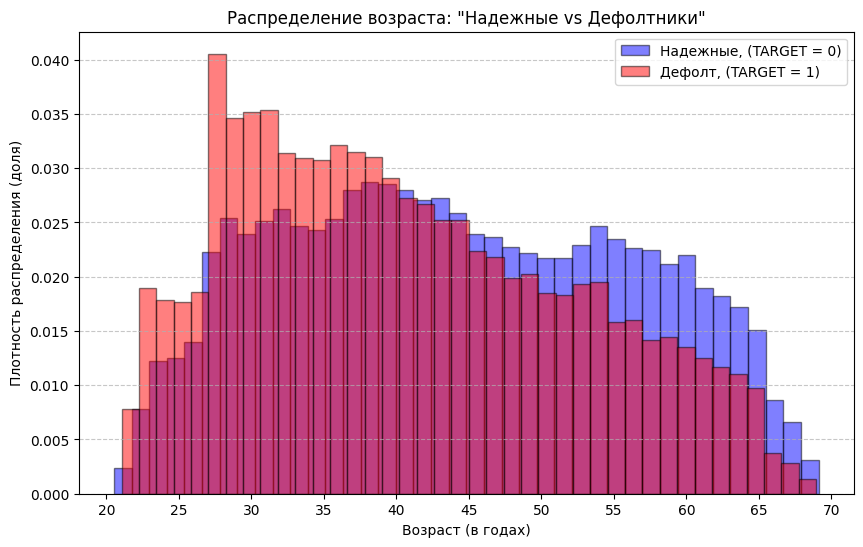

CODE_GENDER
F       6.999363
M      10.142017
XNA     0.000000
Name: TARGET, dtype: float64
Chi-Square p-value: 1.12e-200
Cramer's V: 0.0547


In [157]:
#6 step

df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365
print(df.groupby('TARGET')['AGE_YEARS'].mean())  #здесь видно, что молодые люди склонны к дефолту, но лучше это проверить через T-test


age_good = df[df['TARGET']==0]['AGE_YEARS']
age_bad = df[df['TARGET']==1]['AGE_YEARS']
print(f"P value = {ttest_ind(age_good, age_bad, nan_policy='omit').pvalue:.2e}") #p-value ~ 0, проверим размер эффекта через Cohen's d

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    return (group1.mean() - group2.mean()) / (pooled_std ** 0.5)

d = cohens_d(age_good.dropna(), age_bad.dropna())
print(f"Cohen's d: {d:.3f}")  #cohen's d = 0.288, размер эффекта: (слабый эффект), но он есть

plt.figure(figsize = (10,6))

plt.hist(age_good, alpha = 0.5, edgecolor = 'black', bins = 40, density = True, color = 'blue', label = 'Надежные, (TARGET = 0)')
plt.hist(age_bad, alpha = 0.5, edgecolor = 'black', bins = 40, density = True, color = 'red', label = 'Дефолт, (TARGET = 1)')

plt.xticks(range(20, 75, 5))
plt.title('Распределение возраста: "Надежные vs Дефолтники"')
plt.xlabel('Возраст (в годах)')
plt.ylabel('Плотность распределения (доля)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




print(df.groupby('CODE_GENDER')['TARGET'].mean()*100) #здесь видно, что мужчины более склонны к дефолту чем женщины, но давайте проверим через chi2 test

def cramers_v(col1, col2):
    crosstab = pd.crosstab(col1, col2)

    chi2_stat, p_value, dof, expected = chi2_contingency(crosstab)

    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramer_v = np.sqrt(chi2_stat / (n * min_dim))

    print(f"Chi-Square p-value: {p_value:.2e}")
    print(f"Cramer's V: {cramer_v:.4f}")

    return p_value, cramer_v

p, v = cramers_v(df['CODE_GENDER'], df['TARGET'])  #Cramer's V = 0.0547, размер эффекта: (слабый эффект), но он есть



**💡 Инсайт по демографии:**
* **Возраст:** Т-тест (p-value ~ 0) и Cohen's d (0.288) подтвердили статистически значимую разницу. Более молодые клиенты чаще допускают дефолт.
* **Пол:** V Крамера (0.0547) и тест Хи-квадрат доказали, что мужчины — более рискованные заемщики (10.1% дефолтов), чем женщины (6.9%).

## Шаг 7: Анализ внешних кредитных рейтингов (EXT_SOURCE)
Колонки `EXT_SOURCE_1`, `EXT_SOURCE_2` и `EXT_SOURCE_3` — это нормализованные баллы из внешних источников. Проверим их корреляцию с таргетом и измерим размер эффекта через `Cohen's d`. Ожидается, что это одни из самых мощных предикторов в датасете.

Корреляция внешних источников с вероятностью дефолта:
EXT_SOURCE_3   -0.178918
EXT_SOURCE_2   -0.160470
EXT_SOURCE_1   -0.155316
TARGET          1.000000
Name: TARGET, dtype: float64
EXT_SOURCE_1    56.38
EXT_SOURCE_2     0.21
EXT_SOURCE_3    19.83
dtype: float64
Cohen's d для EXT_SOURCE_1 = 0.60
Cohen's d для EXT_SOURCE_2 = 0.60
Cohen's d для EXT_SOURCE_3 = 0.68


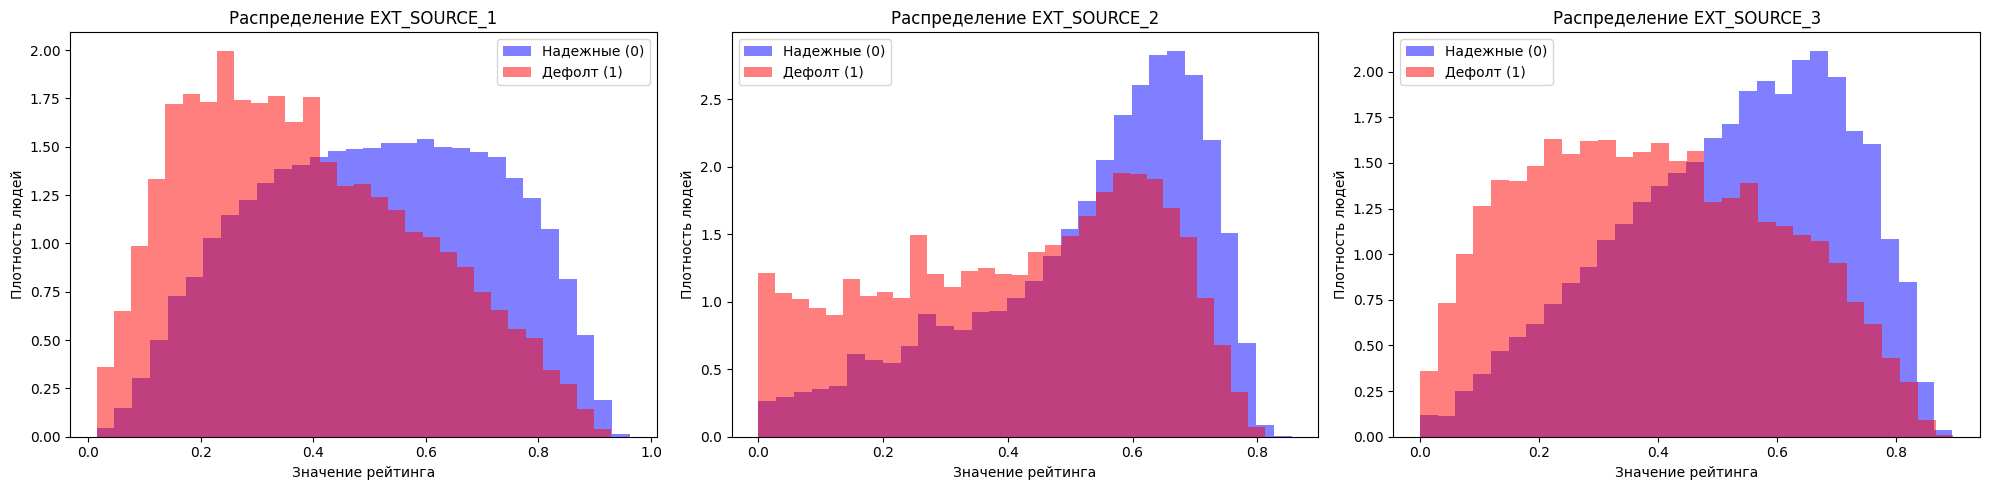

In [158]:
#Анализ внешних кредитных рейтингов (EXT_SOURCE)


ext_data = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]


ext_corrs = ext_data.corr()

print("Корреляция внешних источников с вероятностью дефолта:")

print(ext_corrs['TARGET'].sort_values())


#считаем сколько пропусков в этих трех колонках

print((df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().mean()*100).round(2))


# cohen's d для каждой колонки 

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    good = df[df['TARGET']==0][col].dropna()
    bad = df[df['TARGET']==1][col].dropna()

    d_val = cohens_d(good, bad)
    print(f"Cohen's d для {col} = {abs(d_val):.2f}")




plt.figure(figsize=(20, 5))

sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

for i, col in enumerate(sources):
    
    plt.subplot(1, 3, i + 1)
    
    good = df[df['TARGET'] == 0][col].dropna()
    bad = df[df['TARGET'] == 1][col].dropna()
    
    plt.hist(good, bins=30, alpha=0.5, density=True, color='blue', label='Надежные (0)')
    plt.hist(bad, bins=30, alpha=0.5, density=True, color='red', label='Дефолт (1)')
    
    plt.title(f'Распределение {col}')
    plt.xlabel('Значение рейтинга')
    plt.ylabel('Плотность людей')
    plt.legend()

plt.tight_layout()
plt.show()

**💡 Инсайт: Ловушка дисбаланса и истинная сила EXT_SOURCE**
* **Почему врут расчеты корреляции выше:** Как мы видим в текстовом выводе ячейки, стандартная корреляция Пирсона показывает слабую связь рейтингов с дефолтом (от -0.15 до -0.18). Это происходит из-за **жесткого дисбаланса классов**: огромная масса нулей (92%) математически "топит" единицы, искусственно занижая коэффициент.
* **Истинная картина:** Метрике `Cohen's d` безразличен размер групп. В расчетах выше она выдает огромный размер эффекта — **до 0.68**! Визуально (на гистограммах) мы тоже видим отличную сепарацию. 
**Вывод:** Нельзя слепо доверять коэффициенту корреляции при несбалансированном таргете. Внешние рейтинги — это самые мощные предикторы в датасете.

## Шаг 8: Распределение финансовых показателей
Изучим распределение общих доходов (`AMT_INCOME_TOTAL`), сумм кредита (`AMT_CREDIT`) и ежемесячных платежей (`AMT_ANNUITY`). Используем Boxplot для наглядного сравнения медиан и визуального контроля оставшихся выбросов у надежных клиентов и дефолтников.

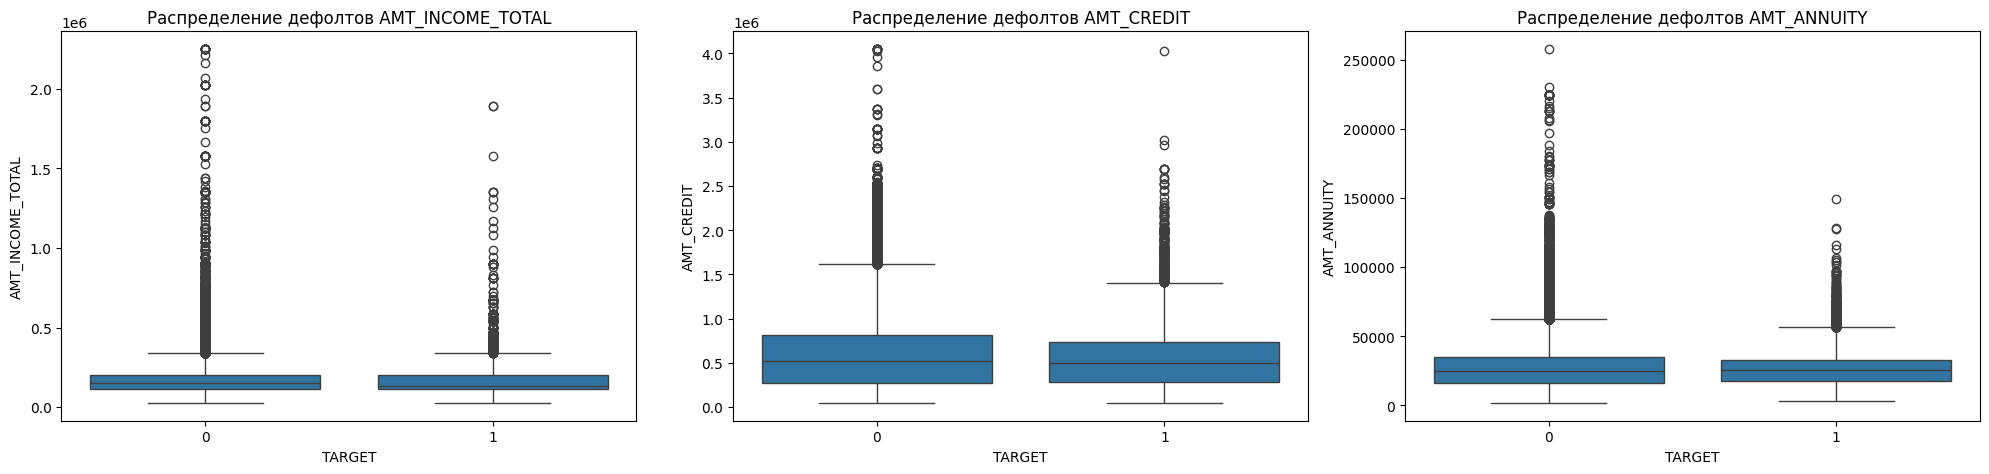

In [159]:
#Числовые распределения (кроме возраста)

plt.figure(figsize = (20,5))

srcs = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

for i, col in enumerate(srcs):
    plt.subplot(1, 3, i + 1)

    sns.boxplot(data=df, x='TARGET', y=col)
    
    plt.title(f'Распределение дефолтов {col}')
    
plt.tight_layout()

plt.show()

**💡 Инсайт: Финансы и почему "голый" доход не работает**
Медианные доходы (`AMT_INCOME_TOTAL`) и размеры кредитов (`AMT_CREDIT`) у надежных клиентов и дефолтников лежат практически на одном уровне. Это разрушает миф о том, что "люди с маленьким доходом не платят". Размер зарплаты сам по себе плохо предсказывает дефолт.
**Вывод для ML:** Финансовые колонки в чистом виде дадут мало пользы. Придется генерировать новые признаки (Feature Engineering) — например, считать **кредитную нагрузку** (какой процент от зарплаты съедает платеж).

## Шаг 9: Влияние образования и семейного положения
Визуализируем категориальные данные (тип образования и семейный статус) с разбивкой по целевой переменной, чтобы понять, какие социальные группы чаще всего берут кредиты и какие из них находятся в зоне риска.

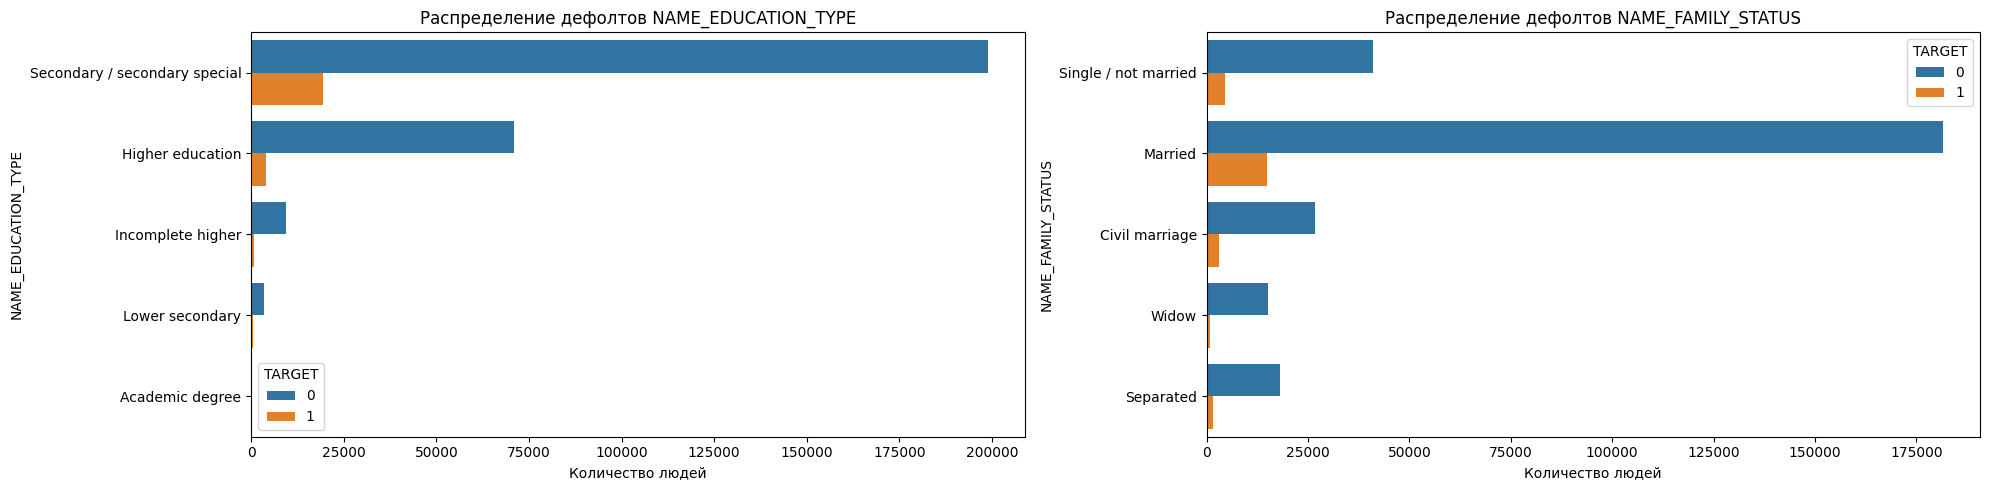

In [160]:
#Категориальные распределения 

cols_to_check = ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

plt.figure(figsize=(20,5))

for i, col in enumerate(cols_to_check):
    plt.subplot(1, 2, i+1)

    sns.countplot(data=df, y=col, hue='TARGET')

    plt.title(f"Распределение дефолтов {col}")
    plt.xlabel('Количество людей')
    
plt.tight_layout()
plt.show()

**💡 Инсайт: Ошибка абсолютных чисел**
График `countplot` создает иллюзию, что женатые люди и клиенты со средним образованием чаще уходят в дефолт (столбцы самые высокие). На деле их просто в несколько раз больше в базе.
Если считать **процент** внутри групп, риск у клиентов с неполным средним образованием самый высокий (~10.9%), а обладатели высшего образования платят лучше всего (~5.3%).

In [161]:

edu_default_rates = (df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100).sort_values(ascending=False)

print("Процент дефолтов по уровню образования:")
print(edu_default_rates.round(2).astype(str) + ' %')

Процент дефолтов по уровню образования:
NAME_EDUCATION_TYPE
Lower secondary                  10.93 %
Secondary / secondary special     8.94 %
Incomplete higher                 8.48 %
Higher education                  5.36 %
Academic degree                   1.83 %
Name: TARGET, dtype: str


## Шаг 10: Поиск мультиколлинеарности (Корреляционная матрица)
Построим тепловую карту (Heatmap) для ключевых числовых признаков. Наша задача:
1. Подтвердить силу связи признаков с `TARGET`.
2. Найти признаки-клоны, которые слишком сильно коррелируют друг с другом (например, сумма кредита и размер платежа), чтобы в будущем избежать проблемы мультиколлинеарности при обучении моделей.

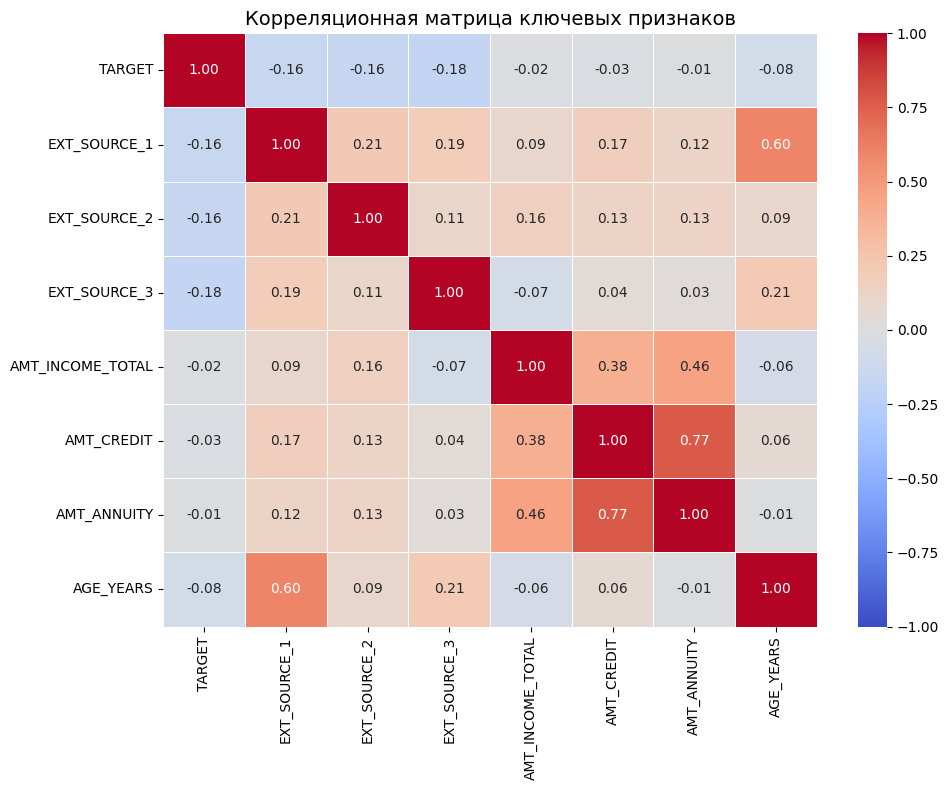

In [162]:
#матрица корреляций 

cols_for_heatmap = ['TARGET', 
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
    'AGE_YEARS']


corr_matrix = df[cols_for_heatmap].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    fmt='.2f',            
    linewidths=0.5,       
    vmin=-1, vmax=1)        

plt.title('Корреляционная матрица ключевых признаков', fontsize=14)
plt.tight_layout()
plt.show()

**💡 Инсайт: Мультиколлинеарность**
Обнаружена сильная прямая связь (**0.77**) между размером кредита (`AMT_CREDIT`) и ежемесячным платежом (`AMT_ANNUITY`). Это очевидная, но важная для ML зависимость (мультиколлинеарность), из-за которой некоторые модели могут переобучиться. Также замечена зависимость внешнего рейтинга `EXT_SOURCE_1` от возраста клиента (0.60).

## Шаг 11: Feature Engineering и Baseline модель (LightGBM)

**💡 План действий:**
1. **Feature Engineering:** Создадим новые финансовые метрики, так как чистые доходы и суммы кредита показали слабую разделительную способность. Мы рассчитаем кредитную нагрузку и долю стажа относительно возраста клиента.
2. **Предобработка категорий:** LightGBM поддерживает категориальные признаки нативно. Вместо One-Hot Encoding мы конвертируем текстовые колонки в category dtype после разбиения на train/test, что устраняет data leakage и упрощает пайплайн.
3. **Обучение Baseline-модели:** Обучим алгоритм `LightGBM`. Чтобы компенсировать сильный дисбаланс таргета, мы укажем модели штрафовать за ошибки на редком классе (`class_weight='balanced'`). В качестве метрики качества будем использовать **ROC-AUC**.

0
0
0


C:\Users\zhaba\AppData\Local\Temp\ipykernel_11420\3451665680.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15888, number of negative: 180917
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9704
[LightGBM] [Info] Number of data points in the train set: 196805, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Трейн: 196805, Вал: 49202, Тест: 61502

🏆 Итоговый ROC-AUC на тестовой выборке: 0.7590


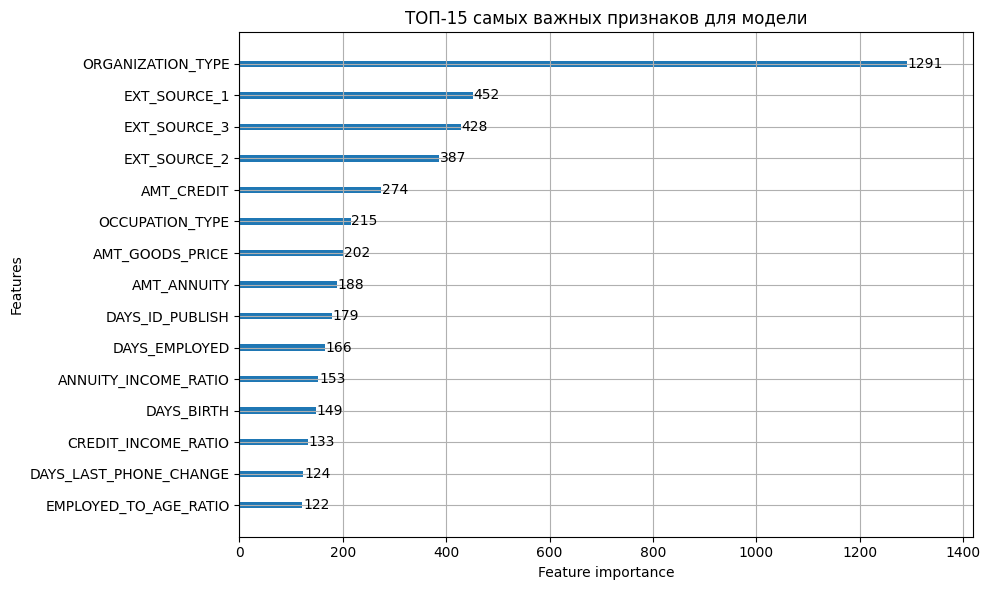

In [ ]:
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['EMPLOYED_TO_AGE_RATIO'] = (df['DAYS_EMPLOYED'] / -365) / df['AGE_YEARS']

#на всякий случай проверяем на inf/NaN
print(np.isinf(df['ANNUITY_INCOME_RATIO']).sum())
print(np.isinf(df['CREDIT_INCOME_RATIO']).sum())
print(np.isinf(df['EMPLOYED_TO_AGE_RATIO']).sum())


# Целевая + признаки (без ID)

y = df['TARGET']
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])

# 1. СПЛИТ до любых преобразований

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

# 2. Находим категориальные колонки

cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

# 3. Конвертируем в category dtype (ПОСЛЕ split!)

for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 4. Модель

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 5. Обучаем с early stopping

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)


# 6. Предсказания

y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Трейн: {X_train.shape[0]}, Вал: {X_val.shape[0]}, Тест: {X_test.shape[0]}")


# Считаем ROC-AUC
roc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\n🏆 Итоговый ROC-AUC на тестовой выборке: {roc_score:.4f}")

# Рисуем график важности признаков
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6), title='ТОП-15 самых важных признаков для модели')
plt.tight_layout()
plt.show()

## Шаг 11.1: Проверка стабильности модели (Cross-Validation)

**Зачем это нужно:** ROC-AUC = 0.7590 был посчитан на одном конкретном разбиении данных (`random_state=42`). Это точечная оценка - она могла оказаться немного выше или ниже просто из-за того, какие именно клиенты случайно попали в тестовую выборку.

Чтобы убедиться, что качество модели - устойчивая закономерность, а не удача конкретного сплита, применим **Stratified 5-Fold Cross-Validation**: данные делятся на 5 частей с сохранением пропорции классов, и модель обучается 5 раз, каждый раз проверяясь на новом, ранее не виденном куске. Если итоговые ROC-AUC по всем 5 циклам близки друг к другу (маленький разброс std) — модель стабильна. Проверка проводится с тем же подходом к категориям (category dtype), что и основная модель.

> **Важно:** проверка проводится на `X_temp`/`y_temp` (данные до финального теста), а не на `X_test` — финальная тестовая выборка остаётся полностью нетронутой для честной итоговой оценки.

In [164]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp)):
    X_tr, X_vl = X_temp.iloc[train_idx].copy(), X_temp.iloc[val_idx].copy()
    y_tr, y_vl = y_temp.iloc[train_idx], y_temp.iloc[val_idx]

    # Конвертируем в category ПОСЛЕ split, внутри фолда
    for col in cat_features:
        X_tr[col] = X_tr[col].astype('category')
        X_vl[col] = X_vl[col].astype('category')

    fold_model = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.05,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    
    fold_model.fit(
        X_tr, y_tr,
        eval_set=[(X_vl, y_vl)],
        eval_metric='auc',
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    preds = fold_model.predict_proba(X_vl)[:, 1]
    score = roc_auc_score(y_vl, preds)
    cv_scores.append(score)
    print(f"Fold {fold+1}: AUC = {score:.4f}")

print(f"\nMean AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15888, number of negative: 180917
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.153141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9689
[LightGBM] [Info] Number of data points in the train set: 196805, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 1: AUC = 0.7622


c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15888, number of negative: 180917
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.070435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9695
[LightGBM] [Info] Number of data points in the train set: 196805, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 2: AUC = 0.7542


c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9706
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 3: AUC = 0.7550


c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9710
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 4: AUC = 0.7530


c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9706
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 5: AUC = 0.7515

Mean AUC: 0.7552 ± 0.0037


**💡 Инсайт по стабильности:** Результаты 5-Fold CV: Mean AUC ≈ 0.7552 ± 0.0037 — модель стабильна, качество не зависит от конкретного разбиения.

## Шаг 12: Проверка на "честность" (Калибровка вероятностей)

**Цель:** Метрика ROC-AUC показывает, насколько хорошо модель *сортирует* клиентов от надежных к рискованным. Однако бизнесу важно, чтобы сами проценты риска были **честными в абсолютных значениях**. Если алгоритм выдает вероятность дефолта 70%, это должно означать, что из 100 таких клиентов в реальности ровно 70 не вернут долг.

Для оценки качества предсказанных вероятностей мы используем:
*   **Brier Score:** Аналог среднеквадратичной ошибки (MSE), но для вероятностей. Чем ближе значение к 0, тем точнее откалибрована модель.
*   **Калибровочная кривая (Reliability Curve):** Визуальное сравнение предсказаний модели с реальной долей дефолтов. 

> **Важный нюанс:** Поскольку при обучении `LightGBM` мы использовали параметр `class_weight='balanced'` для борьбы с жестким дисбалансом классов, модель может агрессивно завышать вероятности дефолта, перестраховываясь. График ниже покажет масштаб этого искажения и поможет принять решение о необходимости дополнительной калибровки (например, через *Platt Scaling* или *Isotonic Regression*) перед расчетом финансовой выгоды.

Brier Score: 0.1851


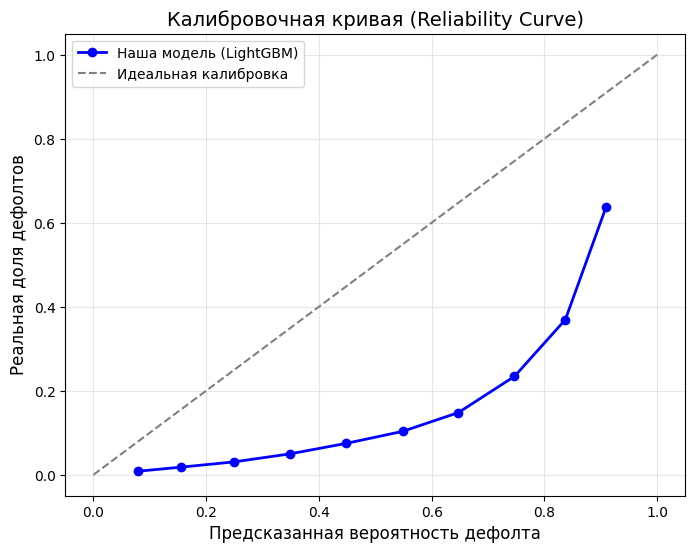

In [165]:


# 1. Считаем Brier Score
brier = brier_score_loss(y_test, y_pred_proba)
print(f"Brier Score: {brier:.4f}")

# 2. Считаем точки для графика (разбиваем людей на 10 корзин по уровню риска)
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

# 3. Рисуем график
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='blue', label='Наша модель (LightGBM)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.title('Калибровочная кривая (Reliability Curve)', fontsize=14)
plt.xlabel('Предсказанная вероятность дефолта', fontsize=12)
plt.ylabel('Реальная доля дефолтов', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Старый Brier Score: 0.1851
Новый Brier Score (после Изотонической регрессии): 0.0677


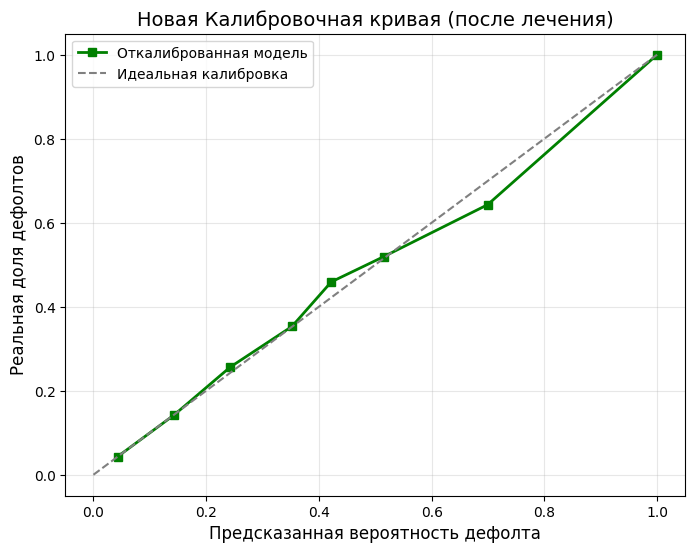

In [166]:



frozen_model = FrozenEstimator(model)

calibrated_model = CalibratedClassifierCV(estimator=frozen_model, method='isotonic')

calibrated_model.fit(X_val, y_val)

y_pred_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

brier_calibrated = brier_score_loss(y_test, y_pred_proba_calibrated)
print(f"Старый Brier Score: {brier:.4f}")
print(f"Новый Brier Score (после Изотонической регрессии): {brier_calibrated:.4f}")

prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_cal, prob_true_cal, marker='s', linewidth=2, color='green', label='Откалиброванная модель')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.title('Новая Калибровочная кривая (после лечения)', fontsize=14)
plt.xlabel('Предсказанная вероятность дефолта', fontsize=12)
plt.ylabel('Реальная доля дефолтов', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Шаг 13: Интерпретируемость модели (SHAP)

**Цель:** Градиентный бустинг — это алгоритм "черного ящика". Чтобы бизнес доверял модели, нам нужно уметь объяснять её логику. 
С помощью библиотеки SHAP (SHapley Additive exPlanations) мы определим:
1. Какие признаки глобально влияют на риск дефолта сильнее всего.
2. Как конкретные значения этих признаков (например, низкий возраст или высокий рейтинг) меняют предсказание.

c:\Users\zhaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


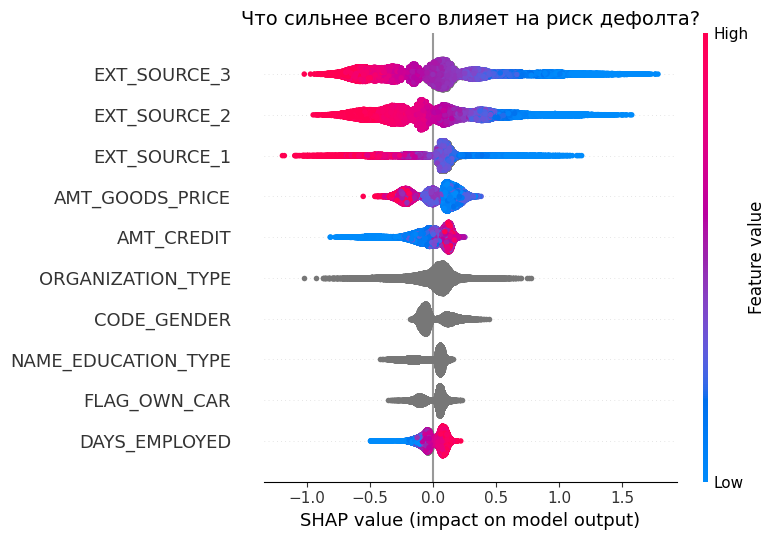

In [167]:

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_val)

# LightGBM для бинарной задачи иногда возвращает массив для двух классов
# Нас интересует класс 1 (дефолт)
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
else:
    shap_values_default = shap_values

plt.title('Что сильнее всего влияет на риск дефолта?', fontsize=14)
shap.summary_plot(shap_values_default, X_val, max_display=10)

## Шаг 14: Бизнес-метрика (Кривая прибыли / Profit Curve)

**Цель:** Перевести предсказания модели в реальные деньги и найти идеальный порог отсечения (threshold). 
Модель выдает риск от 0 до 100%. Если банк будет одобрять кредиты всем подряд (порог 100%), он разорится на дефолтах. Если банк будет одобрять кредиты только идеальным клиентам (порог 1%), он ничего не заработает, так как выдаст слишком мало кредитов. Нам нужно найти математический пик прибыли.

**Условия бизнес-задачи (для примера):**
* Средний размер кредита: 1,000,000 тенге.
* Доходность с хорошего клиента (проценты): 20%.
* Потеря с плохого клиента (дефолт): 100% (теряем всё тело кредита).

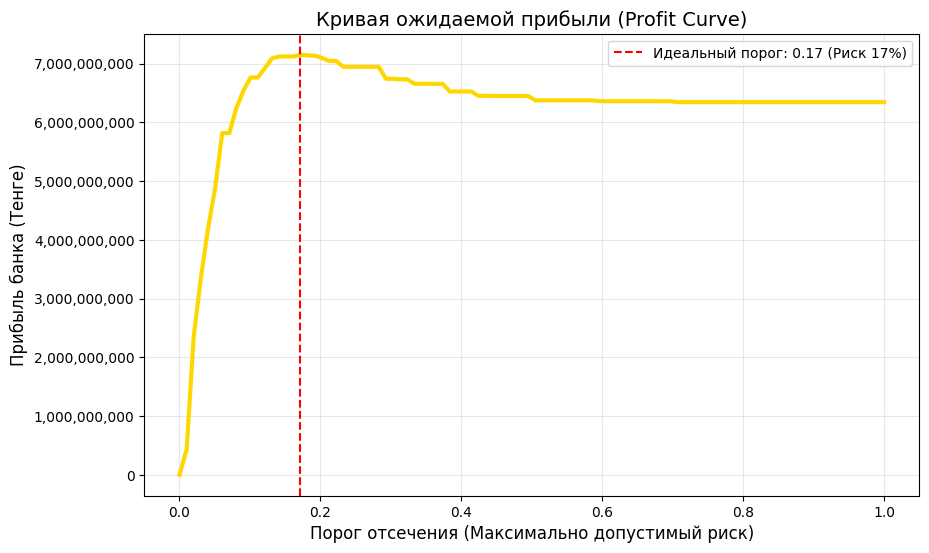

Максимальная прибыль на тестовой выборке: 7,150,800,000 тенге
Банку следует отказывать всем клиентам с риском выше: 17.17%


In [168]:

AVERAGE_LOAN = 1000000  # 1 миллион тенге
INTEREST_RATE = 0.20    # Банк зарабатывает 20% с надежного заемщика
LOSS_RATE = 1.0         # Банк теряет 100% суммы при дефолте

# Вытаскиваем реальные статусы из тестовой выборки
y_true = y_test.values

# Будем тестировать 100 разных порогов строгости (от 0.0 до 1.0)
thresholds = np.linspace(0, 1, 100)
profits = []


for thresh in thresholds:
    # Если риск клиента МЕНЬШЕ порога, мы выдаем ему деньги (True)
    issued_loans = (y_pred_proba_calibrated < thresh)
    
    good_clients = np.sum((issued_loans == True) & (y_true == 0))
    
    bad_clients = np.sum((issued_loans == True) & (y_true == 1))
    
    income = good_clients * AVERAGE_LOAN * INTEREST_RATE
    loss = bad_clients * AVERAGE_LOAN * LOSS_RATE
    total_profit = income - loss
    
    profits.append(total_profit)

# 3. Находим точку максимальной прибыли
max_profit = max(profits)
best_threshold = thresholds[profits.index(max_profit)]

# 4. Рисуем бизнес-график
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, color='gold', linewidth=3)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Идеальный порог: {best_threshold:.2f} (Риск {best_threshold*100:.0f}%)')
plt.title('Кривая ожидаемой прибыли (Profit Curve)', fontsize=14)
plt.xlabel('Порог отсечения (Максимально допустимый риск)', fontsize=12)
plt.ylabel('Прибыль банка (Тенге)', fontsize=12)

# Делаем красивые цифры на оси Y (с разделителями тысяч)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Максимальная прибыль на тестовой выборке: {max_profit:,.0f} тенге")
print(f"Банку следует отказывать всем клиентам с риском выше: {best_threshold:.2%}")